# Supervised Learning: End-to-End Demo


<br><br>


## 1 - Intro


In this notebook, we'll walk through a complete supervised learning project from start to finish for a realistic business problem: **predicting customer churn**.

Our goal is not just to train a model, but to go through the same structured process that is often used in real machine learning projects: understand the problem, explore the data, prepare the dataset, build a baseline model, feature engineering, compare models, tune them, and evaluate the final result carefully.

<br>


### 1.1 - The Dataset

For this demo, we'll use the **Telco Customer Churn** dataset. 

It contains customer data from a telecom company, including demographics, services used, and account information. The target variable indicates whether a customer has churned (left the service) or not.


The original dataset and a description of what each feature represents can be found here: https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data


<br>


### 1.2 - The Business Problem

Our business question is: **can we predict which customers are likely to leave the company?**

This matters because churn usually has a direct cost for the business. If a company can identify high-risk customers early, it may be able to intervene with retention actions such as discounts.

Our target variable is "Churn", which tells us whether a customer left the company or stayed.

Because there are only two possible outcomes (leave vs. stay), this is a **"Binary Classification"** problem.

<br>


### 1.3 - The Metric

For this demo, we will use **F1-score** as the main evaluation metric.

When classes are imbalanced accuracy can be misleading, so we want a metric that gives us a better summary of model quality. F1-score combines **precision** and **recall** into one number, which makes it convenient for comparing multiple models and for tuning hyperparameters.


Some notes on the metric we're choosing:

- For this lesson, F1 is a practical and simple choice that helps us compare different models consistently but it's worth to mention that in many projects, metric selection is often tied to business constraints. 

- For example, a team might use a rule like: “Maximize Recall, but only accept models where Precision is at least 60%”

- That percentage is not arbitrary. It typically depends on factors such as:
    - The cost of contacting each customer (retention campaign cost)
    - The expected profit from successfully retaining a customer
    - The probability that a contacted customer actually stays (effectiveness of the retention action)
    - Operational capacity (how many customers the company can realistically target)


<br><br><br><br>


## 2 - Load the Data



In [1]:
import pandas as pd

#
# load the dataset from a URL:
#

url = "https://raw.githubusercontent.com/ironhack-rmt-AI-student-materials/datasets-ai-eng/main/datasets/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(url)


# Source:
# The original source for this dataset is the "Telco Customer Churn" dataset, from Kaggle
# (https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data)




In [2]:
# 
# check if the data was loaded correctly
# 

pd.set_option('display.max_columns', None) # show all columns in pandas output (no truncation)

display(df)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


<br><br><br><br>


## 3 - Exploratory Data Analysis (EDA)

Before building any model, we need to understand the data. EDA helps us answer questions like:
- What does the data look like?
- Are there missing values or data quality issues?
- How are the features distributed?
- Are there patterns that could help predict churn?


The goal of this step is to understand the data and identify potential issues — not to fix them. If there's anything to fix (class imbalance, wrong data types, missing values, outliers…), we'll do that in the next steps.


<br>

### 3.1 - Dataset Overview

Let's start with a high-level overview: size, column names, and data types.


In [3]:
#
# check the dataset shape
#

df.shape # 7043 rows, 21 columns


(7043, 21)

In [4]:
#
# display 5 random rows
#

df.sample(5, random_state=42)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


In [5]:
#
# list all column names
#

df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

<br>

### 3.2 - Identify the Target Variable

Our target variable is the column `Churn`. 

It tells us whether a customer left the company (`"Yes"`) or stayed (`"No"`).



In [6]:
#
# check the unique values in the target column
#

df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

We can see that it is stored as strings ('Yes' / 'No'). Later on, we'll need to convert it to numeric values (e.g., Yes → 1, No → 0).


<br>

### 3.3 - Check if there's class imbalance

In classification, when one class is much more frequent than others (e.g., 95% "not fraud" vs. 5% "fraud"), a model may predict the majority class and still appear "accurate" but be useless.


In [7]:
#
# measure the class distribution of the target
#

df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


The target variable shows that about 73.5% of customers did not churn and 26.5% did.

This indicates a mild class imbalance, meaning the dataset is not perfectly balanced, but the minority class is still reasonably well represented.

In imbalanced datasets, accuracy is not a reliable evaluation metric, since a model could achieve high accuracy by mostly predicting the majority class. Instead, we will use F1-score as the main evaluation metric, as it better captures the trade-off between precision and recall for the churn class.

Given that the imbalance is mild rather than severe, it does not require aggressive corrective techniques. Instead, we will handle it in a simple and effective way by adjusting class weights to penalize mistakes on the minority class more (e.g., using `class_weight="balanced"` during model training).

For datasets with stronger imbalance (e.g. 90/10 or worse), additional techniques such as oversampling, undersampling, or SMOTE are typically needed to improve model performance. You can find more information [here](https://chatgpt.com/share/69fa7fae-b90c-8330-a91b-f2c39f949fac)

<br>

### 3.4 - Check data types and structure

Before going further, let's inspect how pandas interpreted each column.

This helps us separate numeric and categorical features, and it can also reveal columns whose current type does not match their real meaning.

At this stage, we are only identifying issues. We will fix them later in the data cleaning section.


In [8]:
#
# inspect column names, non-null counts, and inferred data types
#

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
#
# count how many columns belong to each data type
#

df.dtypes.value_counts()

object     18
int64       2
float64     1
Name: count, dtype: int64

In [10]:
#
# Get the number of unique values for object (string/categorical) columns.
# This helps assess cardinality and data structure (e.g., distinguishing IDs from categorical features).
#

object_summary = pd.DataFrame({
    'n_unique': df.select_dtypes(include='object').nunique()
}).sort_values('n_unique', ascending=False)

object_summary

,n_unique
customerID,7043
TotalCharges,6531
PaymentMethod,4
OnlineBackup,3
Contract,3
StreamingMovies,3
StreamingTV,3
TechSupport,3
DeviceProtection,3
OnlineSecurity,3


In [11]:
df.sample(5, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


`TotalCharges` seems suspicious because it's clearly a numeric column but it's stored as an object.

In pandas, a column is stored as object when it contains mixed or unclear data types, so pandas can’t safely assign a more specific type like int64 or string.

If a column with numberical values is stored as object, it's likely because some values are not purely numeric. Common reasons:
- Numbers stored as strings (e.g., "123" instead of 123)
- Mixed types in the column (e.g., numbers + strings like "10" and "N/A")
- Missing or malformed values (e.g., "?", "unknown", or " ")
- Imported data issues (common with CSV/Excel files where pandas can't safely infer numeric type)

<br><br>

Let's check that column in more detail, to understand why it's not stored as a number!



In [12]:
#
# Count how many times each unique value appears in the TotalCharges column.
#
print(df["TotalCharges"].value_counts())

# → An empty value seems to appear 11 times

#
# Get the rows where the value in the column TotalCharges is NOT a valid number (NaN, "hello", "", etc.)
#
converted = pd.to_numeric(df["TotalCharges"], errors="coerce")
not_numeric = converted.isna()
display(df[not_numeric])

# → We can see there's 11 rows that seem to have an empty value in that column"


#
# Display each value in a way that makes hidden details visible (e.g., empty-looking strings or spaces are shown explicitly)
#
df.loc[converted.isna(), "TotalCharges"].apply(repr)

# → We can clearly see the issue. 11 rows have an empty string (" ") in the column TotalCharges

TotalCharges
          11
20.2      11
19.75      9
20.05      8
19.9       8
          ..
6849.4     1
692.35     1
130.15     1
3211.9     1
6844.5     1
Name: count, Length: 6531, dtype: int64


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


488     ' '
753     ' '
936     ' '
1082    ' '
1340    ' '
3331    ' '
3826    ' '
4380    ' '
5218    ' '
6670    ' '
6754    ' '
Name: TotalCharges, dtype: object

From these checks, we can already see the main structure of the dataset:

- We have a mix of numeric columns (`int64`, `float64`) and many `object` columns.
- `customerID` stands out as an identifier rather than a meaningful predictive feature. Since it is unique for each customer, we will likely drop it before modeling (it doesn't seem to have any predictive value and it would only introduce noise that can lower model performance).
- Most `object` columns are categorical features, and many of them are low-cardinality variables such as Yes/No fields. Since most machine learning models expect numeric inputs, we will need to encode these categories into numerical features later.
- `TotalCharges` is an important column to revisit later. 11 rows have missing values (" "), so we'll need to deal with it later when we do data cleaning.

So, at this point, we understand the current structure of the data. In the cleaning step, we will correct the problematic types before training models.

<br>

### 3.5 - Check missing values

Missing values can cause problems later during data cleaning and model training.

Let's start with a standard null-value check:


In [13]:
#
# check missing values with a standard null-value check
#

df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

At first glance, this suggests that the dataset does not contain missing values.

However, in the previous section we already discovered an important nuance: `TotalCharges` contains 11 blank-string values (`" "`). Those are effectively missing values, even though they are not stored as real `NaN` values.

So, the standard null-value check tells us that there are no missing values in the usual pandas sense, but the dataset still contains hidden missing data in `TotalCharges`. We will handle that later in the data cleaning section.

<br>

### 3.6 - Explore data distributions and basic statistics - Numeric columns

Now that we understand the dataset structure and missing-value situation, let's look at how the main features are distributed. This can help identify potential errors in the data, spot skewed numeric variables, dominant categories, and patterns that may matter later for preprocessing and modeling.

First, we'll start with the numeric columns.


In [14]:
#
# summarize the numeric columns
#

# this will give us a summary of stats for numeric columns...
# display(df.describe())


# ...but we know "TotalCharges", so we'll do a bit different:
display(df.assign(TotalCharges=pd.to_numeric(df['TotalCharges'], errors='coerce')).describe())



,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


Here's the meaning for each of those numeric columns (these descriptions are provided with the original dataset and can be found [here](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data)):
- `SeniorCitizen` → "Whether the customer is a senior citizen or not" 
- `tenure` → "Number of months the customer has stayed with the company"
- `MonthlyCharges` →  "The amount charged to the customer monthly"
- `TotalCharges` → "The total amount charged to the customer"

`SeniorCitizen` is stored as a numeric column but represents a binary categorical feature (0 = no, 1 = yes).

All the values that we get from `df.describe()` seem very reasonable. There isn't anything suspicious, like negative values for charges or tenure, unreasonably low or high values, etc.



<br>

Let's render some plots to understand better the numeric features:

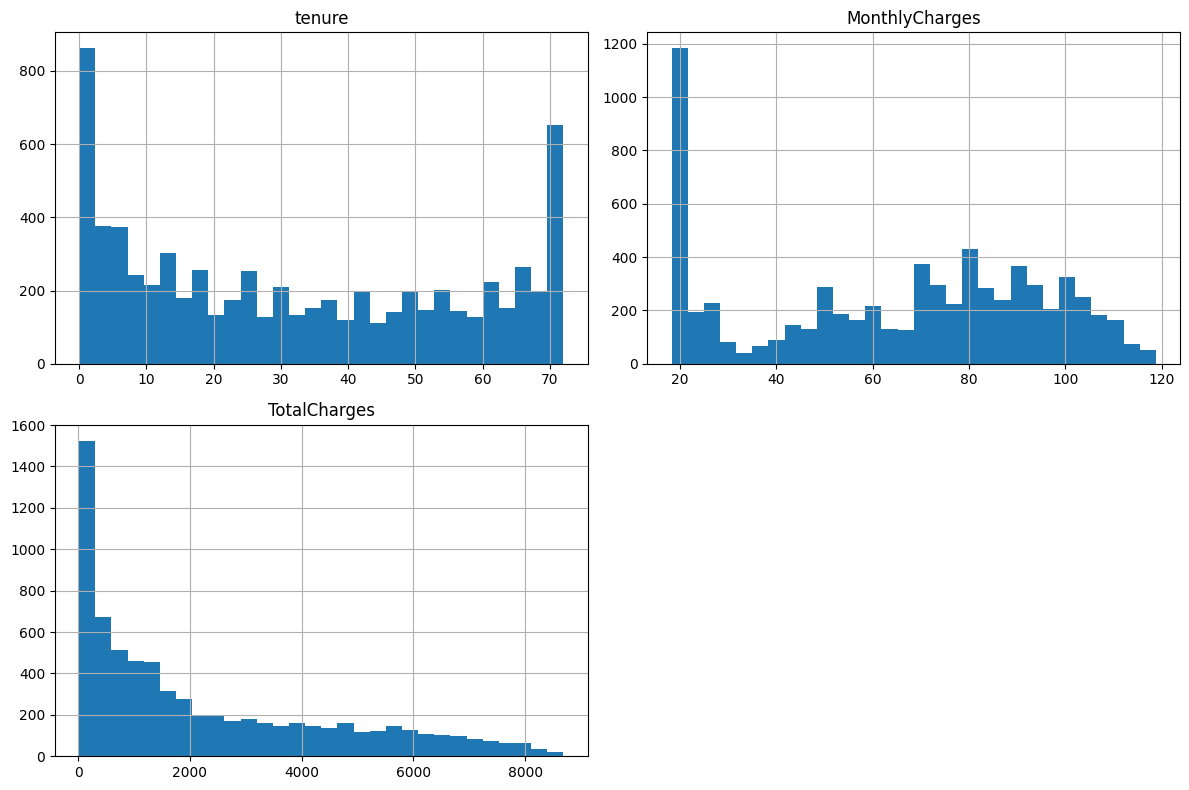

In [15]:
#
# visualize the distribution of the numeric features
#

import matplotlib.pyplot as plt

df_plot = df[['tenure', 'MonthlyCharges']].copy()
df_plot['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df_plot.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()

These charts reveal a few interesting patterns:

- **Tenure**: Many customers are either very new or have stayed for a long time. New customers are probably the ones most likely to churn.
- **MonthlyCharges**: Most customers pay a low monthly fee. Higher-paying customers are fewer but spread across a wide range.
- **TotalCharges:** Most customers have paid a relatively small total amount, with only a few long-term customers reaching very high values (the data is "right-skewed").




<br>

### 3.7 - Explore data distributions and basic statistics - Categorical columns


Let's now analyze the categorical features.

In [16]:
#
# get number of unique values per column (helps detect categorical vs ID-like features)
#

df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [17]:
#
# Display the distribution of values for categorical columns
#


# 1. Select object columns
cat_cols = df.select_dtypes(include="object").columns.tolist()

# 2. Remove columns which we know are not categorical
cat_cols = [col for col in cat_cols if col not in ["customerID", "TotalCharges"]]

# # 3. For each categorical column, display the distribution of its unique values
for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport
TechSupport
No             

The distribution of values that we have for the categorical columns also seem very reasonable. 

There isn't anything suspicious, like unexpected category labels, obvious typos, extremely rare values, or categories that dominate almost the entire column. Overall, the distributions look consistent and clean, which indicates good data quality for these features.



<br>

### 3.8 - Identify correlations between features

Correlation analysis can help us spot numeric features that move together and identify possible redundancy before modeling.

For now, we will focus only on the numeric columns. Most of the categorical features have not been encoded yet, so they are not ready for this type of analysis.


In [18]:
#
# prepare the numeric columns for correlation analysis
#

corr_df = df[['SeniorCitizen', 'tenure', 'MonthlyCharges']].copy()
corr_df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

corr_matrix = corr_df.corr()

display(corr_matrix.round(2))

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.00,0.02,0.22,0.10
tenure,0.02,1.00,0.25,0.83
MonthlyCharges,0.22,0.25,1.00,0.65
TotalCharges,0.10,0.83,0.65,1.00


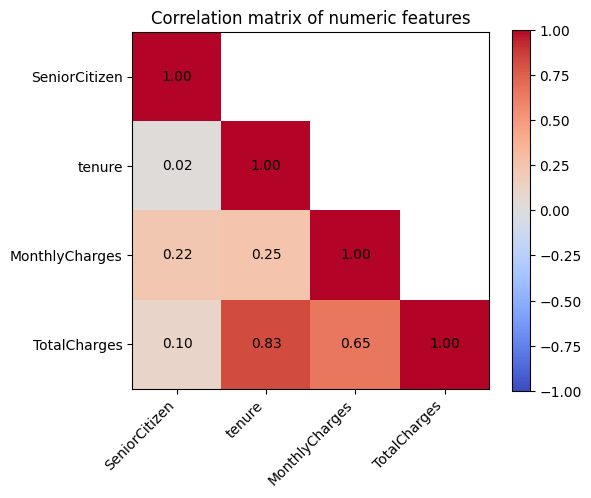

In [19]:
#
# visualize the correlation matrix with a triangular heatmap
#

plt.figure(figsize=(6, 5))

masked_corr = corr_matrix.copy()
for row_index in range(len(masked_corr.index)):
    for col_index in range(len(masked_corr.columns)):
        if col_index > row_index:
            masked_corr.iloc[row_index, col_index] = float('nan')

plt.imshow(masked_corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(masked_corr.columns)), masked_corr.columns, rotation=45, ha='right')
plt.yticks(range(len(masked_corr.index)), masked_corr.index)

for row_index in range(len(masked_corr.index)):
    for col_index in range(len(masked_corr.columns)):
        value = masked_corr.iloc[row_index, col_index]
        if pd.notna(value):
            plt.text(col_index, row_index, f'{value:.2f}', ha='center', va='center', color='black')

plt.title('Correlation matrix of numeric features')
plt.tight_layout()
plt.show()

From this analysis, a few points are worth noting:

- `tenure` and `TotalCharges` are likely to show a strong positive correlation, which makes sense because customers who stay longer usually accumulate more total charges.
- `MonthlyCharges` may also relate to `TotalCharges`, but its relationship with other numeric features is usually weaker.
- `SeniorCitizen` appears as numeric here, but it is really a binary categorical feature, so its correlations should be interpreted with extra care.

At this stage, we are only identifying relationships between features. Later on, this can help us think about redundancy and multicollinearity, especially when we reach feature selection.

<br>

### 3.9 - Check if we have enough data for Machine Learning

Before moving on, we sould also check if the dataset seems large enough to train a reasonable machine learning model.


In [20]:
#
# check the dataset size and the number of rows in each class
#

print('\n\nDataset shape:', df.shape)
print('\n\nClass counts:')
print(df['Churn'].value_counts())



Dataset shape: (7043, 21)


Class counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


The dataset has around 7,000 rows, so from a size perspective it looks large enough to continue with a classical machine learning workflow.

Even though the target is mildly imbalanced, the minority class still has a meaningful number of examples, so the dataset does not seem too small from that point of view either.

And, while we will need to do some data cleaning, data quality also seems good and the available features seem relevant.

Of course, whether a dataset is truly "large enough" always depends on the problem, the quality of the features, and the complexity of the model. But based on this quick check, we seem to have enough data to continue with the next steps.

<br>

### 3.10 - Main conclusions from the EDA

At this point, we have a much clearer picture of the dataset and of the main issues we need to keep in mind before modeling:

- The target variable is `Churn`, and the dataset shows a mild class imbalance. This reinforces why F1-score is a better main metric than accuracy for this problem.
- The dataset is generally clean, but `TotalCharges` needs special attention because it was loaded as `object` and contains 11 hidden missing values stored as blank strings.
- `customerID` appears to be an identifier rather than a useful predictive feature, so we will likely drop it before training models.
- The dataset contains a mix of numeric and categorical features. Many categorical columns are low-cardinality variables, so they will later need to be encoded into numerical features.
- The numeric distributions look reasonable overall. Some of them are skewed, especially `TotalCharges`.
- The categorical columns also look consistent, without obvious typos, strange labels, or suspiciously rare categories.
- `tenure` and `TotalCharges` show a strong relationship, which suggests possible redundancy that may matter later during feature selection.
- The size of the dataset and the quality of the data seem good enough for machine learning.

Overall, the EDA suggests that the dataset is usable, but it still needs a few preprocessing steps before modeling. The next stages will be to split the data, clean the problematic columns, and prepare the features for training.


<br><br><br><br>


## 4 - Data Splitting

Before doing any cleaning, feature engineering, or model training, we should split the data into separate sets.

This is important because we want to avoid **data leakage**:

>
> ℹ️ **Data Leakage**
> 
> In Machine Learning, data leakage occurs when information that would not be available at prediction time is used during training, leading to overly optimistic performance estimates and poor real-world generalization. 
> 
> It’s like studying for an exam using the answer sheet in advance —your results look great during practice, but don't reflect real performance.
> 
> To avoid it, split the data early, and ensure that any transformation that learns from the data (e.g., scaling, encoding, imputation) is fitted only on the training set and then applied to the validation and test sets.
>






<br>

### 4.1 - Common options for splitting data

> ℹ️ Common patterns to split data:
>
> - a) **Train/Test split**: 
>     - Simple and common for quick experiments, but limited when you also want to compare models or tune hyperparameters carefully.
>     - Example: 80% of the data used for training + 20% for testing
> - b) **Train/Validation/Test split**: 
>     - A very practical workflow when you want one set for training, one for model selection, and one final untouched set for evaluation.
>     - Example: 70% of the data used for training + 15% for validation/hyperparameter tuning + 15% reserved for the final testing
> - c) **Cross-validation**: 
>     - Often gives a more robust estimate of performance, especially on smaller datasets, but it also adds more complexity.
>     - Example: 80% of the data used for training, and later reused for hyperparameter tuning with k-fold cross-validation + 20% reserved for the final testing
> 
> 
> ⚠️ Important: Always keep the test set untouched until the end and only use it for final evaluation (to ensure an unbiased performance estimate).
> 



For this notebook, we will use a **Train/Validation/Test** split.

Why this choice? Because it keeps the workflow clear and realistic for teaching the full machine learning process:

- We will train models on the training set.
- We will use the validation set to compare models and tune decisions.
- We will keep the test set untouched until the very end, so it can provide a final unbiased evaluation.

Since this dataset has around 7,000 rows, it is large enough to support this approach without making the lesson more complex. That said, using Cross-validation would also be a very reasonable option.

<br>

> ℹ️ Special cases and things to keep in mind for data splitting:
>
> **Classification problems**: 
> - The split should preserve the proportion of each class across train, validation, and test sets — this is called stratification. For example, if only 5% of your data is labeled "fraud", a random split might leave your test set with very few fraud cases. 
> - In scikit-learn, you can do this by passing stratify=y to train_test_split.
>
> **Time series data**: 
> - Do not use a random split. The split should respect time order, so the model is always trained on the past and evaluated on the future.
> - An essential rule: "Never let the future leak into the past — random splitting for time series is a form of data leakage"
> 
> **Grouped data**: 
> - If multiple rows belong to the same person, customer, device, or company, those groups usually should not be split across train, validation, and test sets.
>
> **Very small datasets**: 
> - Cross-validation is often preferred because a single validation split may waste too much data or give unstable results.
> 






<br>

### 4.2 - Define features and target

We will separate the dataset into:

- `X`: the input features
- `y`: the target variable (`Churn`)

For now, we will keep `Churn` as `"Yes"` / `"No"`, because that is enough for splitting the data. We will convert it later when we prepare the data for modeling.

Also, even though EDA already suggested that `customerID` will likely be removed and `TotalCharges` needs cleaning, we will not do that yet. This section is only about splitting the data.


In [21]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Churn')
y = df['Churn']

<br>

### 4.3 - Create train, validation, and test sets

We will use a final split of:

- 70% for training
- 15% for validation
- 15% for testing

We will also use **stratification** based on the target variable so that each split keeps a similar proportion of churned vs. non-churned customers.

This is especially important here because the dataset has a mild class imbalance.


In [22]:
# first split: train (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# second split: validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

<br>

### 4.4 - Check the size of each split

Let's verify that the split sizes are approximately what we expected.


In [23]:
print('X_train shape:', X_train.shape)
print('X_val shape:  ', X_val.shape)
print('X_test shape: ', X_test.shape)

X_train shape: (4930, 20)
X_val shape:   (1056, 20)
X_test shape:  (1057, 20)


<br>

### 4.5 - Check class balance after the split

Because we used stratification, the churn distribution should remain very similar across training, validation, and test sets.


In [24]:
split_class_balance = pd.DataFrame({
    'train (%)': (y_train.value_counts(normalize=True) * 100).round(2),
    'validation (%)': (y_val.value_counts(normalize=True) * 100).round(2),
    'test (%)': (y_test.value_counts(normalize=True) * 100).round(2)
})

split_class_balance

,train (%),validation (%),test (%)
Churn,,,
No,73.47,73.48,73.42
Yes,26.53,26.52,26.58


We can see that the class proportions remain very close across the three splits, which is exactly what we wanted.

That means the validation and test sets should be representative of the original dataset, making later model comparison and final evaluation more reliable.

Now that the data is split, the next step is to clean the data. From this point on, any preprocessing decisions should be learned from the training set and then applied consistently to validation and test data.


<br><br><br><br>

## 5 - Data Cleaning

<br>

### 5.1 - What do we need to clean?

Based on the EDA, there are two clear cleaning actions to take before modeling:

- Remove `customerID`, because it behaves like a pure identifier rather than a meaningful predictive feature.
- Fix `TotalCharges`, because it should be numeric but currently contains blank-string values that represent missing data.



<br>

### 5.2 - Remove the column `customerID`

In [25]:
X_train_clean = X_train.copy()
X_val_clean = X_val.copy()
X_test_clean = X_test.copy()

for dataset in [X_train_clean, X_val_clean, X_test_clean]:
    dataset.drop(columns='customerID', inplace=True)

print('customerID in X_train_clean:', 'customerID' in X_train_clean.columns)
print('customerID in X_val_clean:', 'customerID' in X_val_clean.columns)
print('customerID in X_test_clean:', 'customerID' in X_test_clean.columns)

customerID in X_train_clean: False
customerID in X_val_clean: False
customerID in X_test_clean: False


<br>

### 5.3 - Inspect the `TotalCharges` issue on the training set

From the EDA, we already know that `TotalCharges` is the main problematic column: it is stored as text because some rows contain a blank string instead of a number.

Before applying a fix everywhere, let's confirm that pattern on the training set and inspect the affected rows.

In [26]:
total_charges_train_check = X_train_clean[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()

total_charges_train_check['TotalCharges_numeric'] = pd.to_numeric(
    total_charges_train_check['TotalCharges'].replace(' ', pd.NA),
    errors='coerce'
 )

missing_total_charges_train = total_charges_train_check[
    total_charges_train_check['TotalCharges_numeric'].isna()
 ]

print('Rows with missing TotalCharges in training:', len(missing_total_charges_train))

display(missing_total_charges_train)

Rows with missing TotalCharges in training: 7


,tenure,MonthlyCharges,TotalCharges,TotalCharges_numeric
6670,0,73.35,,NaN
3826,0,25.35,,NaN
4380,0,20.00,,NaN
488,0,52.55,,NaN
1082,0,25.75,,NaN
6754,0,61.90,,NaN
3331,0,19.85,,NaN


As we can see above, in this dataset the missing-looking values in `TotalCharges` correspond to customers with `tenure = 0`. That makes domain sense: if a customer is brand new, their total charges can reasonably be `0`.

So our cleaning rule will be simple and specific to what we observed in EDA and in the training split:

- Convert `TotalCharges` to a numeric column
- Treat blank strings as missing values
- Fill those missing values with `0`


In [27]:
for dataset in [X_train_clean, X_val_clean, X_test_clean]:
    dataset['TotalCharges'] = pd.to_numeric(
        dataset['TotalCharges'].replace(' ', pd.NA),
        errors='coerce'
    )
    dataset['TotalCharges'] = dataset['TotalCharges'].fillna(0)

<br>

### 5.4 - Final checks after cleaning

Let's confirm that the column `customerID` is gone, `TotalCharges` is now numeric, and no missing values remain in that column.

In [28]:
cleaning_summary = pd.DataFrame({
    'customerID_present': [
        'customerID' in X_train_clean.columns,
        'customerID' in X_val_clean.columns,
        'customerID' in X_test_clean.columns
    ],
    'TotalCharges_dtype': [
        X_train_clean['TotalCharges'].dtype,
        X_val_clean['TotalCharges'].dtype,
        X_test_clean['TotalCharges'].dtype
    ],
    'missing_TotalCharges': [
        X_train_clean['TotalCharges'].isna().sum(),
        X_val_clean['TotalCharges'].isna().sum(),
        X_test_clean['TotalCharges'].isna().sum()
    ]
}, index=['train', 'validation', 'test'])

cleaning_summary

,customerID_present,TotalCharges_dtype,missing_TotalCharges
train,False,float64,0
validation,False,float64,0
test,False,float64,0


At this point, the main cleaning issues identified in the EDA have been addressed:

- `customerID` has been removed from the feature sets
- `TotalCharges` has been converted to a numeric column
- The hidden missing values in `TotalCharges` have been handled

The datasets are now structurally cleaner and ready for the next steps. Later transformations such as encoding, scaling, and feature selection should be fitted on `X_train_clean` and then applied to `X_val_clean` and `X_test_clean`.

<br><br><br><br>


## 6 - Establish a Baseline Model

<br>

### 6.1 - Why start with a baseline?

Before trying more sophisticated models, it is good practice to establish a simple baseline.

A baseline gives us a reference point. If a later model cannot beat the baseline, then it is not really adding value.

For this notebook, we will use a `DummyClassifier` with the `most_frequent` strategy. That means it will always predict the majority class seen in the training data.

This is especially useful here because the dataset is mildly imbalanced. A model that always predicts `"No"` may still get a decent accuracy, but it will do a poor job identifying customers who actually churn.

Also, this baseline can be built **before** feature engineering, because a dummy classifier ignores the feature values entirely. So we can use `X_train_clean` and `X_val_clean` as they are.


In [29]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

majority_class = y_train.mode()[0]
print('Majority class in the training set:', majority_class)

baseline_model = DummyClassifier(strategy='most_frequent')
_ = baseline_model.fit(X_train_clean, y_train)

Majority class in the training set: No



 > ℹ️ **Note**
 > 
 > A `DummyClassifier` is a simple baseline model that ignores input features and makes predictions using basic rules (e.g., always predicting the most frequent class)
 > 
 > In this guide, we're choosing a `DummyClassifier` for simplicity. Another common option in many projects is to train a very simple model as a baseline (e.g., a linear model or a small tree-based model).
 >

<br>

### 6.2 - Evaluate the baseline on the validation set

As in the rest of the notebook, we will keep the test set untouched for now. So we will evaluate this baseline on the validation set.

Because our business goal is to identify churned customers, we will compute the metrics with `"Yes"` as the "positive class".

> ℹ️ What is the positive class?
> 
> In binary classification, the positive class is the outcome we care most about detecting. It is the label treated as the “event” (often encoded as 1) when computing metrics like precision and recall.
> 
> In this case, "Yes" (customer churned) is the positive class because identifying churned customers is our main objective.
> 


In [30]:
y_val_pred_baseline = baseline_model.predict(X_val_clean)

baseline_results = pd.DataFrame({
    'metric': ['Accuracy', 'Precision (churn = Yes)', 'Recall (churn = Yes)', 'F1-score (churn = Yes)'],
    'value': [
        accuracy_score(y_val, y_val_pred_baseline),
        precision_score(y_val, y_val_pred_baseline, pos_label='Yes', zero_division=0),
        recall_score(y_val, y_val_pred_baseline, pos_label='Yes', zero_division=0),
        f1_score(y_val, y_val_pred_baseline, pos_label='Yes', zero_division=0)
    ]
})

baseline_results['value'] = baseline_results['value'].round(3)
baseline_results

,metric,value
0,Accuracy,0.735
1,Precision (churn = Yes),0.000
2,Recall (churn = Yes),0.000
3,F1-score (churn = Yes),0.000


These results are exactly what we would expect from a baseline that always predicts the majority class (`"No"`).

- **Accuracy = 0.735**: this looks decent at first, but it mainly reflects the fact that about 73.5% of customers in the dataset do **not** churn. So, by always predicting `"No"`, the model is correct most of the time.
- **Precision = 0.000** for churn: the model never predicts `"Yes"`, so it never makes a positive churn prediction. Because of that, its precision for the churn class is effectively zero.
- **Recall = 0.000** for churn: the model fails to identify any of the customers who actually churned, so it misses all positive cases.
- **F1-score = 0.000** for churn: since F1 combines precision and recall, and both are zero, the F1-score is also zero.

<br>

This is a perfect example of why **accuracy alone can be misleading**.

> 👉 Accuracy alone can be misleading, especially with class imbalance. 
> 
> A model may achieve high overall accuracy simply by predicting the majority class, yet fail to identify the minority class that matters most for the business goal — in this case, customers who are likely to churn.
>



<br>


At this point, we already have a baseline model and a clear reference point for the rest of the notebook.

So, from now on, any more advanced model should aim to beat this baseline, especially on the churn-related metrics such as recall and F1-score.

<br><br><br><br>


## 7 - Feature Engineering

<br>

### 7.1 - Why feature engineering matters

Our baseline model did not need feature engineering because a `DummyClassifier` ignores the actual feature values.

But real models do depend on the information contained in the features. So, before training more useful models, we need to prepare the dataset in a way that helps those models learn better patterns.

👉 Important: to avoid data leakage, every transformation in this section will be fitted on the training set first, and then applied to validation and test data.

<br>

### 7.2 - Identify numeric and categorical features

Before transforming anything, let's separate the features by type.

In this dataset, `SeniorCitizen` is stored as a number, but it actually represents a categorical variable, so we will treat it as categorical during encoding.

In [31]:
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X_train_clean.columns if col not in numeric_features]

print('Numeric features:', numeric_features)
print('\nCategorical features:')
print(categorical_features)

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


<br>

### 7.3 - Encode categorical variables



> ℹ️ Encoding
> 
> Most machine learning models require numeric inputs to learn from the data.
> 
> **Encoding** is the process of converting categorical (non-numeric) data into numerical values so that models can process it.
> 
> Common encoding techniques:
> 
> - One-hot encoding: 
>   - Creates a separate binary column for each category, where only the column matching the category is set to 1 and all others are 0
>   - Example: color = red → [red=1, blue=0, green=0]
>   - A common variant is **dummy encoding**, which drops one column per feature (the reference category). For example, with 3 colors, instead of 3 columns you get 2 — red is implied when blue=0 and green=0. This avoids perfect multicollinearity between the encoded columns, which can matter for linear models such as logistic regression.
> - Label encoding: 
>   - Assigns an integer to each category
>   - Example: red=0, blue=1, green=2
>   - It is simple, but may introduce false order
> - Ordinal encoding: 
>   - Assigns each category an integer based on a meaningful order. 
>   - Example: small = 0, medium = 1, large = 2
>   - It is used when the categories have a natural ranking, so the numeric values correctly represent relative order, even if the distance between them is not necessarily equal.
> - Target encoding: 
>   - Replaces each category with a value calculated from the target variable for that category (commonly the mean). 
>   - It is useful for categorical features with many unique values and can capture the relationship between the category and the target. However, it can easily overfit if not done carefully (typically requires cross-validation and/or smoothing).
> 

<br>


> ⚠️ Data leakage warning (encoding)
> 
> Encoding steps (e.g., one-hot encoding, ordinal encoding, target encoding) must be fitted only on the training set.
>
> If you compute encodings using the full dataset (including test data), you unintentionally leak information from the test set into training, leading to overly optimistic performance estimates.
> 

<br>



For this dataset, we will use **dummy encoding** (one-hot encoding with `drop='first'`), which drops the first category of each feature as the reference level, avoiding perfect multicollinearity. We will make sure to fit the encoder only on the training data.


In [32]:
from sklearn.preprocessing import OneHotEncoder

# Initialize encoder 
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')

# Fit on training data only, then apply the same encoding to all splits.
#
# Notice that we're using fit_transform() for the training data, and transform() for the validation and test sets.
#
# - fit_transform(): learns the categories from training data and encodes it (dropping the first category per feature)
# - transform(): applies the learned categories without re-learning (prevents data leakage)
X_train_encoded = encoder.fit_transform(X_train_clean[categorical_features])
X_val_encoded = encoder.transform(X_val_clean[categorical_features])
X_test_encoded = encoder.transform(X_test_clean[categorical_features])

# Get the generated column names (e.g. 'color_blue', 'color_green')
encoded_feature_names = encoder.get_feature_names_out(categorical_features).tolist()

# Wrap encoded arrays back into DataFrames, preserving original indices
# (this step is needed because fit_transform/transform return numpy arrays, without column names and index)
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train_clean.index)
X_val_encoded_df = pd.DataFrame(X_val_encoded, columns=encoded_feature_names, index=X_val_clean.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test_clean.index)

# Combine numeric and encoded categorical features into final feature matrices
X_train_fe_input = pd.concat([X_train_clean[numeric_features], X_train_encoded_df], axis=1)
X_val_fe_input = pd.concat([X_val_clean[numeric_features], X_val_encoded_df], axis=1)
X_test_fe_input = pd.concat([X_test_clean[numeric_features], X_test_encoded_df], axis=1)

# Sanity check shapes
print('Encoded training shape:', X_train_fe_input.shape)
print('Encoded validation shape:', X_val_fe_input.shape)
print('Encoded test shape:', X_test_fe_input.shape)


Encoded training shape: (4930, 30)
Encoded validation shape: (1056, 30)
Encoded test shape: (1057, 30)


<br>

Let's compare the data before and after encoding...

In [33]:
print("\n\nTraining data BEFORE encoding...")
display(X_train_clean.sample(4, random_state=59))


print("\n\nTraining data AFTER encoding...")
display(X_train_fe_input.sample(4, random_state=59))




Training data BEFORE encoding...


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
1745,Female,0,Yes,Yes,56,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.80,1119.90
1709,Male,1,No,No,30,Yes,Yes,DSL,No,No,Yes,Yes,Yes,No,Two year,Yes,Credit card (automatic),69.10,2093.90
310,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),19.25,19.25
3444,Male,0,Yes,No,36,No,No phone service,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,35.35,1317.95




Training data AFTER encoding...


,tenure,MonthlyCharges,TotalCharges,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1745,56,19.80,1119.90,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
1709,30,69.10,2093.90,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0
310,1,19.25,19.25,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3444,36,35.35,1317.95,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0



Notice how the original categorical columns — which contained string values like `"Yes"`, `"No"`, or `"Month-to-month"` — have been replaced by binary (0/1) columns.

With dummy encoding (`drop='first'`), one category per feature is dropped as the **reference level** — specifically the first category in alphabetical order. For example, a `Contract` column becomes `Contract_One year` and `Contract_Two year`, with `Contract_Month-to-month` dropped as the reference. A row with both columns set to 0 implies a month-to-month contract.

This reduces the number of columns compared to full one-hot encoding and avoids perfect multicollinearity, which matters for linear models like logistic regression.


<br>

### 7.4 - Signal amplification

Feature engineering is not only about converting text categories into numbers. Sometimes we can also create new features that make useful patterns easier for the model to learn.


> ℹ️ Signal amplification
> 
> Signal amplification refers to transforming or creating features so that meaningful patterns in the data become clearer and easier for a model to learn, compared to noise.
> 
> Common techniques used for signal amplification:
> 
> - Non-linear transformations:
>   - Transform features mathematically to capture non-linear relationships or reduce skew, making patterns easier for models to learn
>   - For example, if we're creating a model to predict energy consumption, and we suspect the relationship with temperature is not linear (very cold and very hot days both increase usage), we can add a polynomial feature to capture this curved effect: `df["temperature_squared"] = df["temperature"] ** 2`
> - Interaction terms:
>   - Combine two or more features to capture joint effects that are not visible in individual features alone
>   - For example, if we're creating a model to predict the risk of heart disease, and we know that the risk of heart disease is higher not just from high blood pressure or high cholesterol alone, but especially when both are high at the same time, we can create a new feature that reflects if a person has both of them at the same time: `df["blood_pressure_cholesterol_interaction"] = df["blood_pressure"] * df["cholesterol"]`
> - Binning:
>   - Turning continuous numerical values into categories
>   - Useful when there are clear thresholds or meaningful ranges in the data (e.g., grouping age into "child / adult / senior"), or when you want simpler, more interpretable features.
>   - Avoid when the exact numeric value carries important signal or when models already capture non-linearities effectively (e.g., tree-based models)
>
>
> Tips:
>   - If you know something about the phenomena that you're studying, try to find the way of encoding it in the data. Signal Amplification can really make the difference between a decent and a great model ⭐️
>   - Domain knowledge is often key. In real-world projects it's common to consult domain experts (e.g. doctors, finance analysts, product teams) to design meaningful features like ratios or transformations that reflect how the system actually behaves.
>

<br><br>


For this dataset, we will create two simple signal-amplification features:

- `is_new_customer`: flags customers with 12 months of tenure or less
- `num_services`: counts how many telecom services a customer is actively using


In [34]:
#
# add a new feature "is_new_customer"
# (flags customers with 12 months of tenure or less)
#

# Flag customers with 12 months of tenure or less as new customers
X_train_fe_input['is_new_customer'] = (X_train_clean['tenure'] <= 12).astype(int)
X_val_fe_input['is_new_customer'] = (X_val_clean['tenure'] <= 12).astype(int)
X_test_fe_input['is_new_customer'] = (X_test_clean['tenure'] <= 12).astype(int)

# check the result
display(X_train_fe_input[['tenure', 'is_new_customer']].head())


,tenure,is_new_customer
5557,5,1
2270,3,1
6930,3,1
2257,60,0
898,12,1


In [35]:
#
# add a new feature "num_services"
# (counts how many telecom services a customer is actively using)
#


# Define which columns represent telecom services
service_columns = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
 ]

# Convert each service column to a binary flag (1 = active, 0 = not active), then sum across columns
def count_active_services(df):
    service_flags = pd.DataFrame(index=df.index)
    service_flags['PhoneService'] = (df['PhoneService'] == 'Yes').astype(int)
    service_flags['MultipleLines'] = (df['MultipleLines'] == 'Yes').astype(int)
    service_flags['InternetService'] = (df['InternetService'] != 'No').astype(int)
    service_flags['OnlineSecurity'] = (df['OnlineSecurity'] == 'Yes').astype(int)
    service_flags['OnlineBackup'] = (df['OnlineBackup'] == 'Yes').astype(int)
    service_flags['DeviceProtection'] = (df['DeviceProtection'] == 'Yes').astype(int)
    service_flags['TechSupport'] = (df['TechSupport'] == 'Yes').astype(int)
    service_flags['StreamingTV'] = (df['StreamingTV'] == 'Yes').astype(int)
    service_flags['StreamingMovies'] = (df['StreamingMovies'] == 'Yes').astype(int)
    return service_flags.sum(axis=1)

# Count the total number of active services per customer across all splits
X_train_fe_input['num_services'] = count_active_services(X_train_clean)
X_val_fe_input['num_services'] = count_active_services(X_val_clean)
X_test_fe_input['num_services'] = count_active_services(X_test_clean)


# check the result
display(X_train_fe_input[['num_services']].head())


,num_services
5557,3
2270,4
6930,3
2257,7
898,6



<br>

### 7.5 - Feature Scaling



> ℹ️ Feature Scaling
> 
> Many machine learning models are sensitive to the magnitude of feature values. If one feature ranges from 0 to 1 and another from 0 to 10,000, a model that computes distances or weighted sums may treat the larger-valued feature as more important, even if it isn't.
> 
> **Feature scaling** transforms numeric features so they are on a comparable scale, helping models learn more fairly across all features.
> 
> Common scaling techniques:
> 
> - **Normalization** (`MinMaxScaler`): 
>   - Rescales values to a fixed range, usually between 0 and 1.
>   - Normalization is useful for distance-based models or neural networks, but it's sensitive to outliers. 
> - **Standardization** (`StandardScaler`):
>   - Transforms values so they have a mean of 0 and a standard deviation of 1. This centers the data and puts all features on the same scale, making it easier for algorithms to compare them fairly — regardless of their original units or ranges.
>   - Standardization is often preferred as a default option because it's more robust to outliers than normalization and works well with most algorithms.
> 
> Which models need scaling?
> - Linear models (e.g. Logistic Regression) and distance-based models (e.g. KNN) are sensitive to the scale of input features and require scaling to work properly
> - Tree-based models (e.g. Decision Trees, Random Forests, and Gradient Boosting) split data by thresholds, so they're indifferent to scale. That said, applying scaling to tree-based models won't hurt them either.
> - When in doubt, scaling is a safe habit.
> 

<br>


> ⚠️ Data leakage warning (scaling)
> 
> Just like encoding, scalers must be fitted only on the training set.
> 
> If you fit the scaler on the full dataset (including validation and test data), information about those sets leaks into training, leading to overly optimistic performance estimates.
> 
> In scikit-learn, use `fit_transform()` on the training set and `transform()` on validation and test sets.
>

<br>


For this demo, we will apply standardization.

We will scale only the continuous and count-based numeric features. One-hot encoded columns and binary flags will remain as 0/1 values.


In [36]:
from sklearn.preprocessing import StandardScaler

continuous_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services']
binary_features = ['is_new_customer']

scaler = StandardScaler()

X_train_fe = X_train_fe_input.copy()
X_val_fe = X_val_fe_input.copy()
X_test_fe = X_test_fe_input.copy()

X_train_fe[continuous_features] = scaler.fit_transform(X_train_fe_input[continuous_features])
X_val_fe[continuous_features] = scaler.transform(X_val_fe_input[continuous_features])
X_test_fe[continuous_features] = scaler.transform(X_test_fe_input[continuous_features])

<br>

Let's compare the data before and after scaling...

In [37]:

print("\n\nTraining data BEFORE scaling...")
display(X_train_fe_input[continuous_features].sample(4, random_state=45))


print("\n\nTraining data AFTER scaling...")
display(X_train_fe[continuous_features].sample(4, random_state=45))




Training data BEFORE scaling...


,tenure,MonthlyCharges,TotalCharges,num_services
5162,8,19.45,159.20,1
775,72,110.65,8065.65,8
1616,53,19.40,1110.35,1
6549,1,56.25,56.25,3




Training data AFTER scaling...


,tenure,MonthlyCharges,TotalCharges,num_services
5162,-0.992994,-1.504602,-0.934680,-1.361800
775,1.604003,1.511210,2.514403,1.642849
1616,0.833019,-1.506256,-0.519753,-1.361800
6549,-1.277041,-0.287695,-0.979590,-0.503329


<br>

### 7.6 - Final checks

Let's confirm that the transformed train, validation, and test sets all have the same columns and contain no missing values.

In [38]:
same_columns = (
    list(X_train_fe.columns) == list(X_val_fe.columns) == list(X_test_fe.columns)
 )

feature_engineering_summary = pd.DataFrame({
    'rows': [len(X_train_fe), len(X_val_fe), len(X_test_fe)],
    'columns': [X_train_fe.shape[1], X_val_fe.shape[1], X_test_fe.shape[1]],
    'missing_values': [
        X_train_fe.isna().sum().sum(),
        X_val_fe.isna().sum().sum(),
        X_test_fe.isna().sum().sum()
    ]
}, index=['train', 'validation', 'test'])

print('Same columns across all splits:', same_columns)
feature_engineering_summary

Same columns across all splits: True


,rows,columns,missing_values
train,4930,32,0
validation,1056,32,0
test,1057,32,0


At this point, the data is model-ready: categorical variables have been encoded, the new signal features have been added, and the numeric variables have been scaled.

The next step will be to decide whether all of these features should stay, or whether some of them should be removed during feature selection.

<br><br><br><br>


## 8 - Feature Selection


<br>

### 8.1 - Why feature selection matters

After feature engineering, we now have many more columns than we started with. Not all of them are equally useful.

Feature selection is the process of deciding which features to keep and which to remove before training a model.

<br>

Why does this matter?

- **Redundant features** can confuse the model, especially linear models, because they introduce multicollinearity (two features carrying the same signal).
- **Irrelevant features** can add noise and hurt generalization.
- **Fewer features** means simpler, faster, and often more interpretable models.

<br>

In this notebook, we will focus on two approaches:

1. Checking for **multicollinearity** among numeric features and removing highly correlated ones
2. Using **domain knowledge** to assess whether any remaining features are unlikely to carry useful signal



<br>

### 8.2 - Check for multicollinearity

In our EDA, we already noticed that `tenure` and `TotalCharges` are strongly correlated. Now that we have clean, numeric data, let's confirm this on the training set.

> ℹ️ **Multicollinearity**
>
> Multicollinearity occurs when two or more features are highly correlated with each other, meaning they carry largely the same information.
>
> This is particularly problematic for **linear models** (like Logistic Regression), because those models estimate a separate coefficient for each feature. When two features are nearly identical, the model struggles to assign stable, meaningful weights to them individually — small changes in the data can lead to very different coefficients, making the model unreliable.
>
> Tree-based models (like Decision Trees or Random Forests) are generally more tolerant of multicollinearity, but removing redundant features still tends to improve model clarity and reduce noise.
>



In [39]:
#
# check the correlation among numeric features in the training set
#

numeric_cols_for_corr = ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services']

corr_fs = X_train_fe[numeric_cols_for_corr].corr()

display(corr_fs.round(2))


,tenure,MonthlyCharges,TotalCharges,num_services
tenure,1.00,0.26,0.83,0.48
MonthlyCharges,0.26,1.00,0.65,0.85
TotalCharges,0.83,0.65,1.00,0.78
num_services,0.48,0.85,0.78,1.00


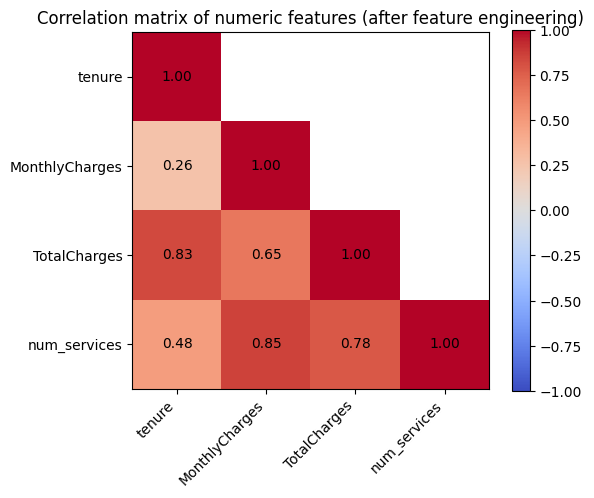

In [40]:
#
# visualize the correlation matrix as a triangular heatmap
#

plt.figure(figsize=(6, 5))

masked_corr_fs = corr_fs.copy()
for row_index in range(len(masked_corr_fs.index)):
    for col_index in range(len(masked_corr_fs.columns)):
        if col_index > row_index:
            masked_corr_fs.iloc[row_index, col_index] = float('nan')

plt.imshow(masked_corr_fs, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()

plt.xticks(range(len(masked_corr_fs.columns)), masked_corr_fs.columns, rotation=45, ha='right')
plt.yticks(range(len(masked_corr_fs.index)), masked_corr_fs.index)

for row_index in range(len(masked_corr_fs.index)):
    for col_index in range(len(masked_corr_fs.columns)):
        value = masked_corr_fs.iloc[row_index, col_index]
        if pd.notna(value):
            plt.text(col_index, row_index, f'{value:.2f}', ha='center', va='center', color='black')

plt.title('Correlation matrix of numeric features (after feature engineering)')
plt.tight_layout()
plt.show()


The matrix reveals several notable correlations:

- **`tenure` ↔ `TotalCharges` (0.83)**: strong positive correlation, as expected from the EDA. Customers who stay longer naturally accumulate more total charges. These two features are largely measuring the same underlying signal.
- **`MonthlyCharges` ↔ `num_services` (0.85)**: the strongest correlation in the matrix. This also makes intuitive sense — customers who subscribe to more services naturally pay a higher monthly bill. These two features are heavily redundant with each other.
- **`TotalCharges` ↔ `num_services` (0.78)** and **`TotalCharges` ↔ `MonthlyCharges` (0.65)**: `TotalCharges` is highly correlated with almost everything, which further confirms it is a derived, redundant feature rather than an independent signal.
- **`tenure` ↔ `MonthlyCharges` (0.26)**: weak correlation, suggesting that how long a customer has stayed is largely independent of what they pay monthly.

The clearest action here is to **drop `TotalCharges`**, which is correlated with all three other features and adds no independent signal. It is essentially a mathematical byproduct of tenure and monthly charges combined.

The `MonthlyCharges` ↔ `num_services` pair (0.85) is also notable. However, both features capture a different perspective — `num_services` reflects engagement and switching costs, while `MonthlyCharges` reflects financial exposure — so we will keep both for now and let the models decide which signal is more useful (if model performance is not as good as expected, this pair would be worth revisiting).



In [41]:
#
# drop TotalCharges from all splits
#

X_train_fs = X_train_fe.drop(columns=['TotalCharges'])
X_val_fs = X_val_fe.drop(columns=['TotalCharges'])
X_test_fs = X_test_fe.drop(columns=['TotalCharges'])

print('TotalCharges removed. New shapes:')
print('  Train:     ', X_train_fs.shape)
print('  Validation:', X_val_fs.shape)
print('  Test:      ', X_test_fs.shape)


TotalCharges removed. New shapes:
  Train:      (4930, 31)
  Validation: (1056, 31)
  Test:       (1057, 31)


<br>

### 8.3 - Review remaining features using domain knowledge

Beyond multicollinearity, another way to approach feature selection is to think about each feature through the lens of **domain knowledge**: does this feature make logical sense as a predictor of churn?

> ℹ️ **Domain knowledge in feature selection**
>
> Domain expertise is often the most powerful tool for feature selection. Asking "does this variable actually make sense as a predictor?" helps filter out features that are noise, even before looking at any statistics.
>
> For example, in a churn prediction problem, it makes intuitive sense that contract type, monthly charges, and tenure would be predictive — customers on month-to-month contracts with high bills and short tenures are logically more likely to leave.
>
> An alternative, more data-driven approach is to train a model (for example, a **Random Forest**) and inspect the **feature importances** it assigns to each column. Features consistently ranked near zero can be candidates for removal. This approach is especially useful when domain knowledge is limited or when the dataset has many features.
>
> In practice, both approaches are often combined.

<br>

Reviewing the features in our dataset with this lens:

- **Demographics** (`gender`, `SeniorCitizen`, `Partner`, `Dependents`): reasonable to expect some relationship with churn
- **Account info** (`tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`): highly relevant — contract type and pricing are strong churn drivers
- **Services** (`PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, etc.): relevant — customers with fewer services or no add-ons may have lower switching costs
- **Engineered features** (`is_new_customer`, `num_services`): both designed to capture known churn patterns (new customers churn more; fewer services = less lock-in)

Based on domain reasoning, all remaining features appear to carry potential signal. We will keep them all and move on to model training.



<br>

### 8.4 - Final feature set summary

Let's confirm the final shape of our feature sets and list all remaining columns.



In [42]:
feature_selection_summary = pd.DataFrame({
    'rows': [len(X_train_fs), len(X_val_fs), len(X_test_fs)],
    'columns': [X_train_fs.shape[1], X_val_fs.shape[1], X_test_fs.shape[1]],
    'missing_values': [
        X_train_fs.isna().sum().sum(),
        X_val_fs.isna().sum().sum(),
        X_test_fs.isna().sum().sum()
    ]
}, index=['train', 'validation', 'test'])

print('Final features kept:')
print(list(X_train_fs.columns))

print()
display(feature_selection_summary)


Final features kept:
['tenure', 'MonthlyCharges', 'gender_Male', 'SeniorCitizen_1', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'is_new_customer', 'num_services']



,rows,columns,missing_values
train,4930,31,0
validation,1056,31,0
test,1057,31,0


The datasets are now ready for model training:

- `TotalCharges` was removed to address the strong multicollinearity with `tenure`
- All remaining features were reviewed through domain knowledge and judged to carry meaningful signal
- Train, validation, and test sets are all aligned and contain no missing values



<br><br><br><br>


## 9 - Handle Class Imbalance

In this section, we will decide if we need to handle class imbalance, and how to do it.


<br>


> ℹ️ **Class imbalance:**
>
> Class imbalance occurs when the categories in a classification dataset are not represented equally — one class has far more samples than another (e.g., 95% "not fraud" vs. 5% "fraud").
> 
> In those cases, a model can appear to perform well simply by predicting the majority class most of the time, while still doing a poor job on the minority class that often matters most for the business problem.
>
> Rule of thumb:
> - 40% – 50% (Balanced): No action required. Standard models usually perform well.
> - 20% – 40% (Mild imbalance): Usually fine. Most algorithms handle this without intervention.
> - 5% – 20% (Moderate imbalance): You should consider handling imbalance.
> - < 5% (Severe imbalance): Strong action is usually required (most models will struggle otherwise).
> 

<br><br>


> ℹ️ **Common techniques to handle class imbalance:**
>
> If you need to address class imbalance, you can apply data-level methods or algorithm-level methods.
> 
> **Data-Level Methods (resampling the data)**:
> - a) Undersample the majority class (discard rows) — simple, but loses data
> - b) Oversample the minority class (duplicate rows) — simple, but risks overfitting
> - c) SMOTE (generate synthetic minority samples) — often a better option than undersampling or oversampling
> - Notes:
>   - If you decide to resample, it can be done now (before you start training and comparing models). Another option is to train and compare models first, and resample only if the performance is not as good as expected.
>   - ⚠️ If you resample, make sure to do it only on the training data. The test set must remain untouched and representative of the true real-world distribution.
>
> **Algorithm-Level Methods (adjusting the model)**: 
> - a) Class weights — penalize mistakes on the minority class more (e.g., in scikit-learn many models have an option class_weight='balanced' to balance class weights) 
> - b) Threshold tuning — define the minority class as the positive class (the class for which the model outputs a probability and applies the decision cutoff) and adjust the probability threshold (e.g., from 0.5 to 0.3). Lowering the threshold increases minority class predictions (higher recall), while raising it makes the model more conservative.
> - c) Combine "Class weights" + "Threshold tuning" — a solid option for severe imbalance.
> - Notes:
>   - If you decide to apply algorithm-level methods, the moment to do it will be when you train models and/or during Hyperparameter Tuning.
> 

<br><br>


>
> ℹ️ **General guidelines for class imbalance:**
>
> - If the dataset is balanced and/or minority-class metrics are strong, you may not need to do anything.
> - If you need to handle class imbalance, start with class weights.
> - If minority recall is still poor, try threshold tuning.
> - If performance is still not good enough, try SMOTE.
>
> ⚠️ Remember that, in imbalanced datasets, accuracy is not a reliable metric. Make sure to evaluate the model and validate improvements using appropriate metrics such as the confusion matrix, precision, recall, F1-score, ROC-AUC, and PR-AUC.

<br><br>



Let's measure the actual class distribution in our training set to decide if any action is needed.


In [43]:
class_counts = y_train.value_counts()
class_pct = (y_train.value_counts(normalize=True) * 100).round(2)

class_balance = pd.DataFrame({
    'count': class_counts,
    'percentage (%)': class_pct
})

print('Class balance in the training set:')
display(class_balance)


Class balance in the training set:


,count,percentage (%)
Churn,,
No,3622,73.47
Yes,1308,26.53


<br>

The training set keeps roughly the same distribution we observed earlier: about 73.5% of customers did not churn and about 26.5% did.

That means this is a **mild imbalance**, not a severe one. The minority class is still well represented, so we have enough churn examples to train and evaluate models in a meaningful way.

Based on those results, we will **not** resample the data (no undersampling, oversampling, or SMOTE). The imbalance is mild, and resampling would discard real data or introduce synthetic samples unnecessarily.

Instead, we will use `class_weight='balanced'` at the algorithm level when training models. This option is available in many scikit-learn classifiers (e.g., LogisticRegression, RandomForestClassifier) and automatically adjusts the loss contribution of each sample so the minority class has more influence during training — without modifying the dataset itself (other libraries provide similar functionality with different parameter names; for example, XGBoost offers `scale_pos_weight`, which works in a similar way).

<br>


> ℹ️ **How `class_weight='balanced'` works**:
>
> With `class_weight='balanced'`, scikit-learn automatically computes a weight for each class that is inversely proportional to its frequency:
> 
> $$w_c = \frac{n\_samples}{n\_classes \times n\_samples\_in\_class_c}$$
> 
> So the minority class (`"Yes"`, ~26.5%) will receive a higher weight, and the majority class (`"No"`, ~73.5%) will receive a lower weight. This encourages the model to treat errors on churned customers as more costly.
> 

<br>

If, during model training, we find that churn recall or F1-score is still too weak, we can consider further action like threshold tuning or resampling.

<br><br><br><br>


## 10 - Train and Compare Different Models

<br>

### 10.1 - Goal of this section

In this section, we will train several reasonable classification models and compare them on the **validation set**. Our main metric will be **F1-score**.

We will train and compare different algorithms using their default settings. Once we've identified the best-performing models, we will apply hyperparameter tuning only to those selected models — this saves time and avoids unnecessary work, since weaker models usually won't outperform stronger ones even after tuning


> ⚠️ Reminder:
> 
> The **test set must remain untouched**. We will only use it at the very end, after model selection and tuning are done.


<br>

### 10.2 - Prepare the target for model training

Our target variable is currently stored as `"Yes"` / `"No"` strings. We will convert it to numeric labels:

- `No` → `0` (customer did **not** churn)
- `Yes` → `1` (customer **did** churn)

This is a common preprocessing step — while most scikit-learn models can handle string labels just fine, some libraries like **XGBoost require numeric targets**. Converting now keeps things consistent across all models we'll train.

We apply the same mapping to the training, validation, and test sets.



In [44]:
target_mapping = {'No': 0, 'Yes': 1}

y_train_num = y_train.map(target_mapping)
y_val_num = y_val.map(target_mapping)
y_test_num = y_test.map(target_mapping)


# Display some examples
display(y_train.sample(4, random_state=71)) # before
display(y_train_num.sample(4, random_state=71)) # after


2617    Yes
6632    Yes
6728     No
4896     No
Name: Churn, dtype: object

2617    1
6632    1
6728    0
4896    0
Name: Churn, dtype: int64

<br>

### 10.3 - Create a reusable evaluation helper

To keep the comparison clean, we will define a small helper function that trains a model and returns the main metrics we care about.

We will store:

- F1-score for the training set (this will help us spot potential overfitting)
- accuracy, precision, recall, and F1-score for the validation set


In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def evaluate_classifier(model, model_name, X_train, y_train, X_val, y_val):

    # Train the model on the training data (ignore returned fitted model)
    _ = model.fit(X_train, y_train)

    # Compute the predictions on training and validation sets
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Return a dictionary with performance metrics for the model
    #
    # note: we use "zero_division=0" to handle cases where there are no positive predictions (to avoid division by zero); returns 0 instead of raising an error or producing NaN
    #
    return {
        'model': model_name,
        'train_f1': f1_score(y_train, y_train_pred, zero_division=0),
        'val_accuracy': accuracy_score(y_val, y_val_pred),
        'val_precision': precision_score(y_val, y_val_pred, zero_division=0),
        'val_recall': recall_score(y_val, y_val_pred, zero_division=0),
        'val_f1': f1_score(y_val, y_val_pred, zero_division=0)
    }

model_results = []

<br>

### 10.4 - Logistic Regression

A good first real model for this kind of tabular binary classification problem is **Logistic Regression**.

It is simple, fast, interpretable, and often surprisingly strong on structured datasets after proper preprocessing.

We will use `class_weight="balanced"` so the churn class has more influence during training.


In [46]:
from sklearn.linear_model import LogisticRegression

log_reg_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

logistic_regression_result = evaluate_classifier(
    log_reg_model,
    'Logistic Regression',
    X_train_fs,
    y_train_num,
    X_val_fs,
    y_val_num
)

model_results.append(logistic_regression_result)
pd.DataFrame([logistic_regression_result]).round(3)

,model,train_f1,val_accuracy,val_precision,val_recall,val_f1
0,Logistic Regression,0.628,0.74,0.506,0.818,0.625


<br>

### 10.5 - Logistic Regression with stronger regularization

> ℹ️ **Regularization**:
> 
> Regularization is a technique used to discourage a model from becoming too complex or relying too heavily on particular features. In practice, it helps reduce overfitting and can improve how well the model generalizes to new data.
>
> Common types of regularization include:
>
> - **L1 regularization**: encourages some coefficients to become exactly zero, which can also act as a form of feature selection. Useful when you suspect many features are irrelevant and you want automatic feature selection.
> - **L2 regularization**: shrinks coefficients toward zero more smoothly, without usually forcing them to become exactly zero. Useful when most features are relevant but you want to reduce over-reliance on any single one.
> - **Elastic Net**: combines L1 and L2. Useful when you expect correlated features and want both stability (L2) and sparsity (L1).
> 



In scikit-learn, `LogisticRegression` uses **L2 regularization by default**. We can also explicitly choose the type of regularization, for example with `penalty='l1'` or `penalty='l2'`.

Another important parameter is `C`. In scikit-learn, `C` is the **inverse** of regularization strength:
- Default value: `C=1.0`
- Smaller `C` → stronger regularization
- Larger `C` → weaker regularization

So if we reduce `C`, the model becomes more constrained. If we increase `C`, the model is allowed to fit the training data more freely.

For this demo, we will train a second logistic regression model with **L2 regularization** and a **smaller `C` value**. That means we are keeping the same type of penalty, but applying **stronger regularization** to see whether the model generalizes better on the validation set.


In [47]:
log_reg_regularized_model = LogisticRegression(
    class_weight='balanced',
    penalty='l2',
    C=0.3,
    max_iter=1000,
    random_state=42
)

logistic_regression_regularized_result = evaluate_classifier(
    log_reg_regularized_model,
    'Logistic Regression (L2, C=0.3)',
    X_train_fs,
    y_train_num,
    X_val_fs,
    y_val_num
)

model_results.append(logistic_regression_regularized_result)
pd.DataFrame([logistic_regression_regularized_result]).round(3)

,model,train_f1,val_accuracy,val_precision,val_recall,val_f1
0,"Logistic Regression (L2, C=0.3)",0.63,0.739,0.504,0.818,0.624


For this particular dataset and this particular `C` value, adding stronger L2 regularization does **not** seem beneficial. At most, the difference is very small. This suggests that the original logistic regression was already in a good range.

<br>

### 10.6 - Decision Tree

Decision Trees can capture non-linear patterns and interactions naturally, without requiring us to define them manually.

They are easy to interpret and handle both numerical and categorical data, but a single tree can easily overfit and is sensitive to small changes in the data.


In [48]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

decision_tree_result = evaluate_classifier(
    decision_tree_model,
    'Decision Tree',
    X_train_fs,
    y_train_num,
    X_val_fs,
    y_val_num
)

model_results.append(decision_tree_result)
pd.DataFrame([decision_tree_result]).round(3)

,model,train_f1,val_accuracy,val_precision,val_recall,val_f1
0,Decision Tree,0.995,0.721,0.474,0.486,0.48


From the results above, the **Decision Tree seems to be overfitting quite strongly**.

Its training F1-score is almost perfect (`0.995`), but its validation F1-score drops sharply to about `0.480`. Validation precision and recall are also fairly modest, which means the model does not generalize nearly as well as its training performance suggests.

This is a common pattern with a single decision tree: it can learn the training data very closely, but that flexibility can hurt performance on new, unseen data.

Tuning hyperparameters like `max_depth` can help, but at this stage, Logistic Regression looks like the better trade-off between simplicity and performance.

<br>

### 10.7 - Random Forest

A Random Forest is an ensemble of many decision trees. Compared with a single tree, it is usually more stable and less prone to overfitting.


In [49]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

random_forest_result = evaluate_classifier(
    random_forest_model,
    'Random Forest',
    X_train_fs,
    y_train_num,
    X_val_fs,
    y_val_num
)

model_results.append(random_forest_result)
pd.DataFrame([random_forest_result]).round(3)

,model,train_f1,val_accuracy,val_precision,val_recall,val_f1
0,Random Forest,0.996,0.768,0.579,0.457,0.511


<br>

### 10.8 - XGBoost

Gradient boosting methods are often among the strongest performers on structured tabular datasets. For this demo, we will use XGBoost.


XGBoost is not part of the standard scikit-learn installation, so you may need to install it in your environment. Here's how to do it:
- With `pip`: `pip install xgboost`
- With `conda`: `conda install -c conda-forge xgboost`




In [50]:
from xgboost import XGBClassifier

#
# First, we will compute `scale_pos_weight`, a parameter that helps handle class imbalance (similar to class_weight in scikit-learn).
#
# It is calculated as the ratio of negative to positive samples — telling XGBoost how much more weight to give the minority class (churners) during training.
#

scale_pos_weight = (y_train_num == 0).sum() / (y_train_num == 1).sum()
print(f'scale_pos_weight for XGBoost: {scale_pos_weight:.2f}')


#
# Now we will train a simple XGBoost model using `scale_pos_weight` to account for the mild class imbalance.
#

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_result = evaluate_classifier(
    xgb_model,
    'XGBoost',
    X_train_fs,
    y_train_num,
    X_val_fs,
    y_val_num
)

model_results.append(xgb_result)
pd.DataFrame([xgb_result]).round(3)

scale_pos_weight for XGBoost: 2.77


,model,train_f1,val_accuracy,val_precision,val_recall,val_f1
0,XGBoost,0.712,0.75,0.518,0.814,0.633


<br>

### 10.9 - Compare all models

Now that all models have been trained, we can compare them side by side:


In [51]:
comparison_df = pd.DataFrame(model_results)

# Compute the difference between training and validation F1 (larger gap = more overfitting)
comparison_df['f1_gap'] = comparison_df['train_f1'] - comparison_df['val_f1']

# Rank models by validation F1 (best first) and reset the index for a clean comparison table
comparison_df = comparison_df.sort_values(by='val_f1', ascending=False, na_position='last').reset_index(drop=True)

display(comparison_df.round(3))



,model,train_f1,val_accuracy,val_precision,val_recall,val_f1,f1_gap
0,XGBoost,0.712,0.750,0.518,0.814,0.633,0.078
1,Logistic Regression,0.628,0.740,0.506,0.818,0.625,0.003
2,"Logistic Regression (L2, C=0.3)",0.630,0.739,0.504,0.818,0.624,0.006
3,Random Forest,0.996,0.768,0.579,0.457,0.511,0.485
4,Decision Tree,0.995,0.721,0.474,0.486,0.480,0.516


When reading the results, these are the most important things to look at:
- `val_f1` (Validation F1-score): this tells us which models perform better on unseen data, according to our main evaluation metric (F1).
- `f1_gap` (Train-vs-validation gap): this is the difference between training and validation F1. A large value suggests the model is overfitting -the model memorized training data but doesn't generalize well.
- `val_precision`, `val_recall` (Validation precision and recall): this can help understand the trade-off between catching churners and avoiding too many false positives

<br><br>

> ℹ️ General rule of thumb when choosing models to tune:
> - Prioritize the models with the strongest validation performance on your main metric
> - Use the train–validation gap as a diagnostic for overfitting and stability; if a model shows clear overfitting without meaningful performance gains, avoid it.
> - When performance is similar, prefer simpler models for better stability and interpretability

<br><br>


Analysis:
- XGBoost is currently the strongest model overall: it has the best validation F1-score while still keeping a high recall.
- The plain Logistic Regression model is also very strong: its validation F1-score is close to XGBoost, its recall is slightly higher, and its train-vs-validation gap is extremely small, which suggests very stable generalization. 
- The stronger-regularized logistic regression performs almost the same but does not improve validation performance, so it does not add clear value.
- Random Forest and Decision Tree are less promising. Even though their training F1-scores are almost perfect, their validation F1-scores are much lower and their train-vs-validation gaps are very large. That is a strong sign of overfitting. 

Decision:
- Based on these results, the best models to move forward into hyperparameter tuning are **XGBoost** and **Logistic Regression**. XGBoost is the top performer on validation F1, and Logistic Regression is close behind while being simpler and more stable. Those two models give us the most sensible next step for tuning.



<br><br><br><br>


## 11 - Hyperparameter Tuning

<br>

### 11.1 - Goal of this section

In the previous section, we identified **XGBoost** and **Logistic Regression** as the two most promising models.

Now we will do a small round of **hyperparameter tuning** to see whether we can improve their validation performance.

<br>

> ℹ️ **Hyperparameter tuning:**
> 
> Hyperparameter tuning is the process of finding the best configuration settings for a model — values that aren't learned from data but set before training begins.
> 
> Examples of hyperparameters:
> - In Logistic Regression, `C` controls the strength of regularization
> - In XGBoost, `max_depth`, `learning_rate`, and `n_estimators` control model complexity and learning speed
>
>
> Common options for hyperparameter tuning:
> - Manual Search: manually try specific values based on intuition or domain knowledge; useful for quick checks or when the number of combinations is very small
> - Grid Search: tries all combinations within a predefined grid of values
> - Random Search: samples random combinations
>

<br>

For this notebook, we will use a **manual search** instead of a large automated search. That keeps the workflow easy to follow and is enough for the purpose of this demo.

<br>

> ⚠️ Reminder:
> 
> We will keep using the **validation set** to compare tuned models.
> 
> The **test set must remain untouched** until the final evaluation section.

<br>

### 11.2 - Manual search for Logistic Regression

For Logistic Regression, the most natural hyperparameter to tune here is `C`, which controls regularization strength.

- Smaller `C` -> stronger regularization
- Larger `C` -> weaker regularization

We will keep the rest of the setup fixed and test a small range of `C` values around the models we already tried.

In [52]:
# define a list with the values that we'll test for C.
# 
# note: C controls regularization strength, and can have a range from 0 (very strong regularization) to infinity (almost no regularization).
log_reg_c_values = [0.05, 0.1, 0.3, 1.0, 3.0, 10.0, 20.0]

# list to store evaluation results for each tested value of C
# (each entry will contain performance metrics for a trained model)
log_reg_tuning_results = []

# train and evaluate Logistic Regression with different values of C
for c_value in log_reg_c_values:
    candidate_model = LogisticRegression(
        class_weight='balanced',
        penalty='l2',
        C=c_value,
        max_iter=1000,
        random_state=42
    )

    result = evaluate_classifier(
        candidate_model,
        f'Logistic Regression (C={c_value})',
        X_train_fs,
        y_train_num,
        X_val_fs,
        y_val_num
    )
    result['C'] = c_value
    log_reg_tuning_results.append(result)

# turn the collected results into a comparison table
log_reg_tuning_df = pd.DataFrame(log_reg_tuning_results)

# measure the train-vs-validation F1 gap to help spot overfitting
log_reg_tuning_df['f1_gap'] = log_reg_tuning_df['train_f1'] - log_reg_tuning_df['val_f1']

# rank models by validation F1 (best first) and reset the index for a clean comparison table
log_reg_tuning_df = log_reg_tuning_df.sort_values(by='val_f1', ascending=False).reset_index(drop=True)

# keep the best C value and refit the tuned Logistic Regression model
best_log_reg_row = log_reg_tuning_df.iloc[0]
best_log_reg_C = float(best_log_reg_row['C'])

best_log_reg_tuned_model = LogisticRegression(
    class_weight='balanced',
    penalty='l2',
    C=best_log_reg_C,
    max_iter=1000,
    random_state=42
)
_ = best_log_reg_tuned_model.fit(X_train_fs, y_train_num)

# store a short summary for the final tuned-model comparison
best_log_reg_tuned_result = {
    'model': f'Logistic Regression (tuned, C={best_log_reg_C})',
    'train_f1': best_log_reg_row['train_f1'],
    'val_accuracy': best_log_reg_row['val_accuracy'],
    'val_precision': best_log_reg_row['val_precision'],
    'val_recall': best_log_reg_row['val_recall'],
    'val_f1': best_log_reg_row['val_f1']
}

print(f'Best Logistic Regression C: {best_log_reg_C}')
display(log_reg_tuning_df.round(3))

Best Logistic Regression C: 10.0


,model,train_f1,val_accuracy,val_precision,val_recall,val_f1,C,f1_gap
0,Logistic Regression (C=10.0),0.627,0.741,0.507,0.821,0.627,10.00,0.000
1,Logistic Regression (C=3.0),0.627,0.740,0.505,0.821,0.626,3.00,0.001
2,Logistic Regression (C=0.05),0.631,0.741,0.508,0.814,0.626,0.05,0.005
3,Logistic Regression (C=1.0),0.628,0.740,0.506,0.818,0.625,1.00,0.003
4,Logistic Regression (C=20.0),0.628,0.740,0.506,0.818,0.625,20.00,0.003
5,Logistic Regression (C=0.1),0.629,0.739,0.504,0.818,0.624,0.10,0.005
6,Logistic Regression (C=0.3),0.630,0.739,0.504,0.818,0.624,0.30,0.006


From the table above, the best validation F1-score comes from **`C=10.0`**, but the differences across all tested values are extremely small.

A few things stand out:

- The whole tuning range performs very similarly: validation F1 is very similar for all values of C.
- Precision and recall are also very stable across the different `C` values
- The train-vs-validation F1 gap is almost zero in every case, which suggests Logistic Regression is generalizing very consistently and is **not** showing meaningful overfitting here

So, for this dataset, tuning `C` does **not** materially change performance. It mainly confirms that Logistic Regression was already in a very good range. We will keep the best-performing version (`C=10.0`) and move on, but the main takeaway is that this model is strong and stable regardless of the exact `C` value we choose within this tested range.

<br>

### 11.3 - Manual search for XGBoost

XGBoost has many possible hyperparameters. For this guide, we will focus on three important ones:

- `max_depth`: controls how complex each tree can become
- `learning_rate`: controls how quickly the model updates from one boosting round to the next
- `n_estimators`: controls how many trees are built

To keep the notebook simple and reasonably fast to run, we will test a small hand-picked set of configurations around the strong baseline we already found.

In [53]:
# define a small set of XGBoost configurations to test
xgb_candidates = [
    {'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 3},
    {'n_estimators': 300, 'learning_rate': 0.03, 'max_depth': 4},
    {'n_estimators': 500, 'learning_rate': 0.03, 'max_depth': 4},
    {'n_estimators': 200, 'learning_rate': 0.05, 'max_depth': 3},
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4},
    {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 3},
    {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 3},
    {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 4}
]

xgb_tuning_results = []

# train and evaluate one XGBoost model for each candidate configuration
for params in xgb_candidates:
    candidate_model = XGBClassifier(
        n_estimators=params['n_estimators'],
        learning_rate=params['learning_rate'],
        max_depth=params['max_depth'],
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )

    result = evaluate_classifier(
        candidate_model,
        'XGBoost candidate',
        X_train_fs,
        y_train_num,
        X_val_fs,
        y_val_num
    )
    result.update(params)
    xgb_tuning_results.append(result)


# turn the collected results into a comparison table
xgb_tuning_df = pd.DataFrame(xgb_tuning_results)

# measure the train-vs-validation F1 gap to help spot overfitting
xgb_tuning_df['f1_gap'] = xgb_tuning_df['train_f1'] - xgb_tuning_df['val_f1']

# rank models by validation F1 (best first) and reset the index for a clean comparison table
xgb_tuning_df = xgb_tuning_df.sort_values(by='val_f1', ascending=False).reset_index(drop=True)

# extract the best hyperparameters from the tuning table
best_xgb_row = xgb_tuning_df.iloc[0]
best_xgb_params = {
    'n_estimators': int(best_xgb_row['n_estimators']),
    'learning_rate': float(best_xgb_row['learning_rate']),
    'max_depth': int(best_xgb_row['max_depth'])
}

# refit XGBoost using the best configuration
best_xgb_tuned_model = XGBClassifier(
    n_estimators=best_xgb_params['n_estimators'],
    learning_rate=best_xgb_params['learning_rate'],
    max_depth=best_xgb_params['max_depth'],
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
_ = best_xgb_tuned_model.fit(X_train_fs, y_train_num)

# store a short summary for the final tuned-model comparison
best_xgb_tuned_result = {
    'model': (
        'XGBoost (tuned, '
        f"n_estimators={best_xgb_params['n_estimators']}, "
        f"learning_rate={best_xgb_params['learning_rate']}, "
        f"max_depth={best_xgb_params['max_depth']})"
    ),
    'train_f1': best_xgb_row['train_f1'],
    'val_accuracy': best_xgb_row['val_accuracy'],
    'val_precision': best_xgb_row['val_precision'],
    'val_recall': best_xgb_row['val_recall'],
    'val_f1': best_xgb_row['val_f1']
}

print('Best XGBoost parameters:')
print(best_xgb_params)
display(xgb_tuning_df.round(3))

Best XGBoost parameters:
{'n_estimators': 200, 'learning_rate': 0.03, 'max_depth': 3}


,model,train_f1,val_accuracy,val_precision,val_recall,val_f1,n_estimators,learning_rate,max_depth,f1_gap
0,XGBoost candidate,0.646,0.747,0.514,0.854,0.642,200,0.03,3,0.004
1,XGBoost candidate,0.709,0.749,0.517,0.821,0.634,500,0.03,4,0.074
2,XGBoost candidate,0.683,0.747,0.514,0.825,0.634,300,0.03,4,0.049
3,XGBoost candidate,0.712,0.750,0.518,0.814,0.633,300,0.05,4,0.078
4,XGBoost candidate,0.676,0.741,0.508,0.832,0.631,200,0.10,3,0.046
5,XGBoost candidate,0.659,0.738,0.503,0.832,0.627,200,0.05,3,0.032
6,XGBoost candidate,0.690,0.741,0.507,0.818,0.626,500,0.05,3,0.064
7,XGBoost candidate,0.759,0.752,0.522,0.775,0.624,300,0.10,4,0.135


From the table above, the best validation F1-score comes from the configuration with **`n_estimators=200`**, **`learning_rate=0.03`**, and **`max_depth=3`**.

A few patterns are worth highlighting:

- The best result comes from the **simplest and most conservative** configuration in the group
- That same configuration also has the **smallest train-vs-validation F1 gap**, which is a strong sign of stable generalization
- More aggressive settings (especially deeper trees, higher learning rates, or more estimators) often increase training F1 noticeably, but they do **not** improve validation F1
- In one of the cases, with `learning_rate=0.1`, `max_depth=4`, `n_estimators=300`, the train F1 becomes much higher, but validation F1 drops and the gap grows a lot, which suggests clear overfitting

So, for this dataset, the main takeaway is that **a simpler XGBoost model works better than a more complex one**. Tuning was still useful, because it helped us find a version that improves validation F1 while keeping overfitting under control. We will keep this best-performing configuration and carry it into the final comparison.

<br>

### 11.4 - Compare the tuned finalists and choose a model

Now that we have the best tuned version of each shortlisted model, we can compare them against their untuned versions.

Out goal is to check whether tuning produced a meaningful improvement and then choose the most sensible model to carry into the final test-set evaluation.


In [54]:
# compare the tuned and untuned finalists in one table
tuned_model_comparison = pd.DataFrame([
    {**logistic_regression_result, 'model': 'Logistic Regression (untuned)'},
    best_log_reg_tuned_result,
    {**xgb_result, 'model': 'XGBoost (untuned)'},
    best_xgb_tuned_result
])

# add the F1 gap and rank models by validation F1
tuned_model_comparison['f1_gap'] = tuned_model_comparison['train_f1'] - tuned_model_comparison['val_f1']
tuned_model_comparison = tuned_model_comparison.sort_values(by='val_f1', ascending=False).reset_index(drop=True)

# choose the top validation performer for final test-set evaluation
final_model_name = tuned_model_comparison.loc[0, 'model']

if final_model_name.startswith('XGBoost'):
    final_model = best_xgb_tuned_model
else:
    final_model = best_log_reg_tuned_model

print('Selected final model for test-set evaluation:')
print(final_model_name)
display(tuned_model_comparison.round(3))

Selected final model for test-set evaluation:
XGBoost (tuned, n_estimators=200, learning_rate=0.03, max_depth=3)


,model,train_f1,val_accuracy,val_precision,val_recall,val_f1,f1_gap
0,"XGBoost (tuned, n_estimators=200, learning_rat...",0.646,0.747,0.514,0.854,0.642,0.004
1,XGBoost (untuned),0.712,0.750,0.518,0.814,0.633,0.078
2,"Logistic Regression (tuned, C=10.0)",0.627,0.741,0.507,0.821,0.627,0.000
3,Logistic Regression (untuned),0.628,0.740,0.506,0.818,0.625,0.003


From the table above, the best model is the **tuned XGBoost** version. It has the highest validation F1-score and a very small train-vs-validation gap, which suggests good generalization.

This comparison also tells us something important about tuning itself:
- **XGBoost benefited from tuning**: the tuned version slightly improves validation F1, while also reducing the overfitting gap substantially (which means less overfitting and better generalization)
- **Logistic Regression remains very stable**, and tuning changes it only marginally

<br>


 > ℹ️ **Model selection in many industry projects**
 > 
 > Performance metrics are very important, but they are usually **not the only factor** when choosing a final model.
 > 
 > Other factors often matter too:
 > - **Simplicity and interpretability**: simpler models are often easier to explain and debug
 > - **Training and prediction cost**: some models are more expensive or slower to run
 > - **Ease of deployment and maintenance**: simpler models are often easier to put into production and monitor over time
 > - **Stability and robustness**: teams may prefer a model that behaves more consistently, even if its score is slightly lower
 > - **Business or regulatory constraints**: in some settings, explainability or reproducibility may be essential
 > 

<br>

For this notebook, we will pick the **tuned XGBoost model**, since it gives us the strongest validation performance while still generalizing well, which makes it a better final candidate.

However, it is worth to mention that choosing a more simple model like Logistic Regression can be a very reasonable choice, specially if performance metrics are very similar.


<br><br><br><br>


## 12 - Final Evaluation on Test Set 

<br>

### 12.1 - Evaluate the final model on the test set

Now that we have selected our final model, we can evaluate it on the untouched test set.

This is the first and only time we use the test set. The goal is to estimate how well the model is likely to perform on new, unseen churn data.

<br>

> ⚠️ **One-shot rule:** We use the test set only **once** — after all decisions are final.
>
> If we used test results to tune hyperparameters or swap models, we'd just be overfitting to that data, and the final score wouldn't reflect real-world performance.

<br>


In [55]:
# Use the final model to make predictions on the test set
y_test_pred_final = final_model.predict(X_test_fs)

# Calculate the main evaluation metrics
test_metric_values = {
    'Accuracy': accuracy_score(y_test_num, y_test_pred_final),
    'Precision (churn = Yes)': precision_score(y_test_num, y_test_pred_final, zero_division=0),
    'Recall (churn = Yes)': recall_score(y_test_num, y_test_pred_final, zero_division=0),
    'F1-score (churn = Yes)': f1_score(y_test_num, y_test_pred_final, zero_division=0)
}

# Put the metrics into a small table
test_results = pd.DataFrame({
    'metric': list(test_metric_values.keys()),
    'value': list(test_metric_values.values())
})

# Round the results to 3 decimals
test_results['value'] = test_results['value'].round(3)

# Compare test F1 with validation F1
validation_f1 = tuned_model_comparison.loc[
    tuned_model_comparison['model'] == final_model_name, 'val_f1'
].iloc[0]
test_f1 = test_metric_values['F1-score (churn = Yes)']

# Show validation and test F1 side by side
validation_vs_test = pd.DataFrame({
    'split': ['validation', 'test'],
    'F1-score': [validation_f1, test_f1]
})

# Display the final results
print('Final model selected for test evaluation:')
print(final_model_name)
print('\nTest-set metrics:')
display(test_results)
print('\nValidation vs test F1-score:')
display(validation_vs_test.round(3))

Final model selected for test evaluation:
XGBoost (tuned, n_estimators=200, learning_rate=0.03, max_depth=3)

Test-set metrics:


,metric,value
0,Accuracy,0.748
1,Precision (churn = Yes),0.517
2,Recall (churn = Yes),0.790
3,F1-score (churn = Yes),0.625



Validation vs test F1-score:


,split,F1-score
0,validation,0.642
1,test,0.625


The test-set results look solid overall.

- **Accuracy = 0.748**: the model is correct most of the time, but accuracy is not the main metric we care about here.
- **Precision = 0.517**: when the model predicts churn, it is correct a little more than half of the time.
- **Recall = 0.790**: the model catches most of the customers who actually churn, which is very useful for this problem.
- **F1-score = 0.625**: this is a reasonable final result because it balances precision and recall.

Also, the test F1-score (`0.625`) is close to the validation F1-score (`0.642`), which suggests that the model generalizes fairly well to unseen data.

<br>

### 12.2 - Confusion matrix

The metrics we've used give us a summary, but the confusion matrix shows the exact types of mistakes the model makes.

For churn prediction, false negatives mean we missed customers who were actually going to leave, while false positives mean we would spend retention effort on customers who were not going to churn.

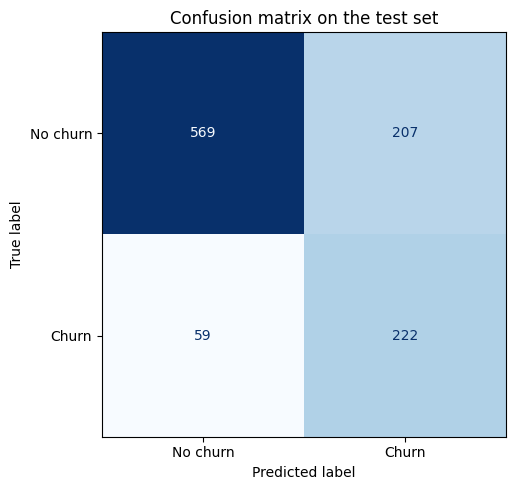

True negatives: 569
False positives: 207
False negatives: 59
True positives: 222


In [56]:
# Import the tools for the confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix and unpack the 4 counts
conf_matrix = confusion_matrix(y_test_num, y_test_pred_final)
tn, fp, fn, tp = conf_matrix.ravel()

# Create the display object for the plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=conf_matrix,
    display_labels=['No churn', 'Churn']
)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
ax.set_title('Confusion matrix on the test set')
plt.tight_layout()
plt.show()

# Print the raw counts for easier discussion
print('True negatives:', tn)
print('False positives:', fp)
print('False negatives:', fn)
print('True positives:', tp)


The confusion matrix shows that the model is doing a good job catching churners overall.

- **True positives = 222**: many customers who actually churned were correctly identified.
- **False negatives = 59**: the model misses some churners, but not too many.
- **False positives = 207**: the model also flags quite a few customers who would not churn.

So, the model is stronger at finding churners than at being very precise. That matches the high recall and more moderate precision we saw earlier.

This is specially useful for many business cases where identifying churners is the main priority (e.g. if missing a customer is expensive compared to the cost of a retention campaign).


<br><br><br><br>


## 13 - Exporting our model (Pickle)

<br>


> ℹ️ **Pickle**:
> 
> `pickle` is a Python module used to save and load trained models (or any Python object) by serializing them into a file.
> 
> It is useful because:
> - You can store a trained model after fitting it, instead of retraining every time.
> - You can reuse the model later for predictions.
> - It helps in moving models between environments (e.g., from training script to production script).
> 
> Syntax:
> - Export a model as a pickle file → `pickle.dump(model, file)`
> - Load a model from a pickle file → `model = pickle.load(file)`
> 
> ⚠️ Note: pickle files are not safe to load from untrusted sources, because they can execute arbitrary code. Treat them like executable programs -only load pickle files that you created yourself or fully trust.
> 


<br>

### 13.1 - Save the final model



Now that we have a final model, we can save it to a file using `pickle`.

This is useful because training a model can take time, and we usually do not want to repeat that work every time we need predictions. By saving the trained model, we can reuse the exact same fitted version later in another notebook, script, or application.



In [57]:
from pathlib import Path

# define the location of our pickle file
model_path = Path('churn_model_v1.pkl')

In [58]:
import pickle

# save the model
with open(model_path, 'wb') as file:
    pickle.dump(final_model, file)

print(f'Model saved to: {model_path.resolve()}')

Model saved to: /Users/luis/Desktop/prep-AI-Eng/repo-w2d3---supervised-learning---end-to-end-demo/churn_model_v1.pkl


<br>

### 13.2 - Load the model back

Loading the saved model is useful because it shows how we can recover a trained model in a new session and use it again right away.


In practice, this is what lets a model move beyond training: instead of fitting it again, we can load it and use it to make predictions whenever we need it.

In [59]:
# load the model
with open(model_path, 'rb') as file:
    loaded_model = pickle.load(file)

loaded_model

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [60]:
# Quick demo: compare if the predictions from the pickled model match the predictions from the original model

original_predictions = final_model.predict(X_test_fs.head(12))
loaded_predictions = loaded_model.predict(X_test_fs.head(12))

print('\nPredictions from the original model:')
print(original_predictions)

print('\nPredictions from the "pickled" model:')
print(loaded_predictions)

print('\nPredictions match?\n', (original_predictions == loaded_predictions).all())


Predictions from the original model:
[1 0 0 0 0 0 0 0 0 1 1 0]

Predictions from the "pickled" model:
[1 0 0 0 0 0 0 0 0 1 1 0]

Predictions match?
 True


<br>


For this lesson, we kept the export step very simple by saving only the trained model.

To fully replicate the process on new data, we would usually also save the preprocessing steps (for example, the encoder, scaler, and final feature list), so the model can be used more easily on new raw data. For that purpose, using scikit-learn Pipelines can be very useful, as they let you chain preprocessing steps and a model into a single object.



<br><br><br><br>


## 14 - Conclusion & Key Takeaways

In this notebook, we walked through a complete supervised learning workflow for a churn prediction problem: from understanding the business goal and exploring the data to training, comparing, tuning, and evaluating models.

The main goal was not just to get a model, but to follow a clear process that can be reused in many real machine learning projects.

### Key takeaways

- Start with the business problem and choose an evaluation metric that matches the goal.
- Split the data early to avoid data leakage.
- Use EDA and data cleaning to find issues before modeling.
- Build a baseline first so you have a clear point of comparison.
- Feature engineering and selection are critical in classical Machine Learning, often making the difference in model performance.
- Keep the test set untouched until the end. Use the validation set (or cross-validation) to compare and tune models.
- The best model is not always the most complex one; simplicity and stability also matter.

Overall, this same workflow can be applied to many other supervised learning problems, not just churn prediction.